FINTECH CHURN INTELLIGENCE

Customer Segmentation & Cohort Analysis

Objective

This notebook analyzes customer cohorts and segments to identify
retention patterns and churn behavior.

Key goals:

- Analyze churn across age and geography cohorts
- Compare retention patterns across customer segments
- Identify high-risk groups requiring intervention
- Explore product and activity-based customer behavior
- Generate retention-focused recommendations

Business Question

Which customer cohorts show the highest churn risk and where should
the retention team focus its efforts?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../01_Data/Churn_Modelling.csv')

df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

print(df.shape)
df.head()

(10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
cohort = df.groupby('Tenure')['Exited'].agg(
    total_customers='count',
    churned_customers='sum',
    churn_rate='mean'
)

cohort['churn_rate'] = round(cohort['churn_rate']*100,2)

cohort

,total_customers,churned_customers,churn_rate
Tenure,,,
0,413,95,23.00
1,1035,232,22.42
2,1048,201,19.18
3,1009,213,21.11
4,989,203,20.53
5,1012,209,20.65
6,967,196,20.27
7,1028,177,17.22
8,1025,197,19.22


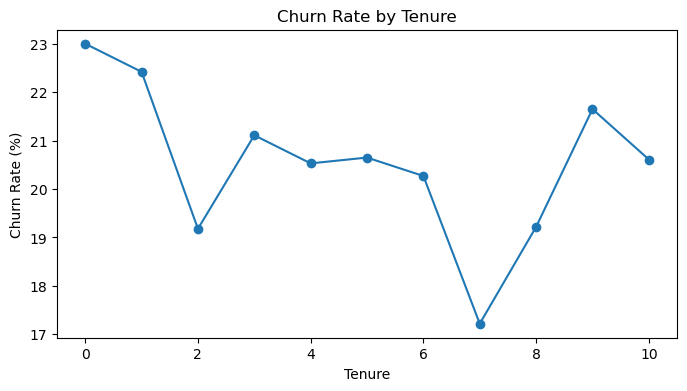

In [6]:
cohort['churn_rate'].plot(
    kind='line',
    marker='o',
    figsize=(8,4)
)

plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Churn Rate (%)')

plt.show()

Customers with certain tenure groups show higher churn.
This indicates customer lifecycle stage influences retention behavior.

In [7]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

heatmap_data = pd.pivot_table(
    df,
    values='Exited',
    index='Geography',
    columns='Age_Group',
    aggfunc='mean'
)*100

round(heatmap_data,2)

/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_39090/3374187877.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


Age_Group,18-30,31-40,41-50,51-60,60+
Geography,,,,,
France,4.87,9.52,28.12,52.59,19.91
Germany,12.53,20.94,48.82,69.55,38.94
Spain,8.47,9.30,27.30,45.99,20.83


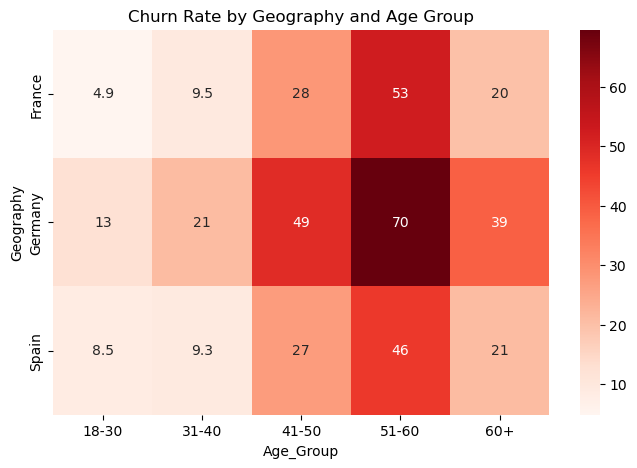

In [8]:
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='Reds'
)

plt.title('Churn Rate by Geography and Age Group')

plt.show()

Germany customers aged 51-60 represent the highest churn segment.
This segment should be prioritized for retention campaigns.

In [9]:
activity = df.groupby('IsActiveMember')['Exited'].agg(
    total_customers='count',
    churned_customers='sum',
    churn_rate='mean'
)

activity['churn_rate'] = round(activity['churn_rate']*100,2)

activity

,total_customers,churned_customers,churn_rate
IsActiveMember,,,
0,4849,1302,26.85
1,5151,735,14.27


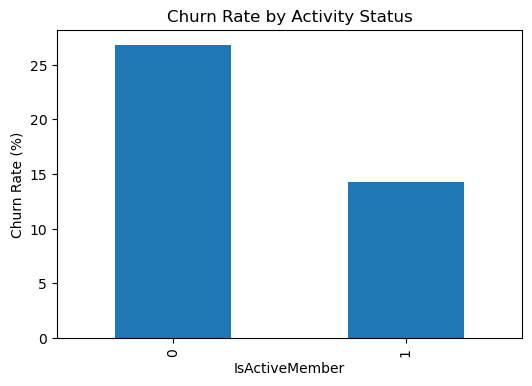

In [10]:
activity['churn_rate'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Activity Status')
plt.ylabel('Churn Rate (%)')

plt.show()

Inactive customers churn significantly more than active customers.
Customer engagement appears to be a major retention driver.

In [11]:
products = df.groupby('NumOfProducts')['Exited'].mean()*100
round(products,2)

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

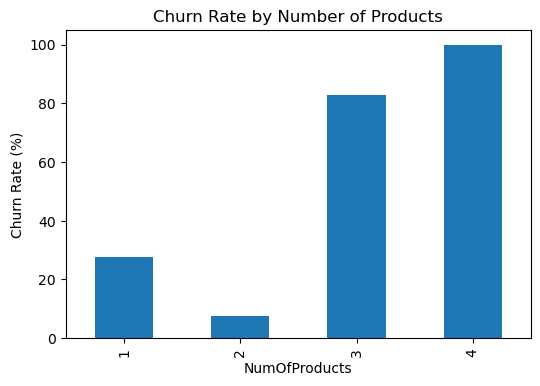

In [12]:
products.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate (%)')

plt.show()

Customers holding two products show the lowest churn.
Cross-selling additional products may improve retention.


Executive Summary
1. Tenure influences churn behavior.
2. Germany + Age 51-60 is the highest-risk segment.
3. Inactive customers churn significantly more.
4. Customers with 2 products show strongest retention.
5. Customer engagement and cross-sell initiatives are key retention opportunities.
